## Task 1: Load the Dataset & Display First 10 Records

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# Load datasets directly from GitHub URLs
train_url = "https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/bigmart_train.csv"
test_url = "https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/bigmart_test.csv"

df = pd.read_csv(train_url)

df.head(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


## Task 2: Dataset Shape & Data Types

In [20]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}\n")
print("--- Data Types ---")
print(df.dtypes)
print("\n--- Dataset Info ---")
df.info()

Number of Rows: 8523
Number of Columns: 12

--- Data Types ---
Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64
dtype: object

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type           

## Task 3: Detect and Report Missing Values

In [23]:
missing_vals = df.isnull().sum()
missing_perc = (missing_vals / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_vals,
    'Percentage (%)': missing_perc.round(2)
})

print("Missing Values Report:")
missing_df

Missing Values Report:


,Missing Count,Percentage (%)
Item_Identifier,0,0.00
Item_Weight,1463,17.17
Item_Fat_Content,0,0.00
Item_Visibility,0,0.00
Item_Type,0,0.00
Item_MRP,0,0.00
Outlet_Identifier,0,0.00
Outlet_Establishment_Year,0,0.00
Outlet_Size,2410,28.28
Outlet_Location_Type,0,0.00


## Task 4: Perform Data Cleaning

In [24]:
# Standardize Item_Fat_Content categories
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat', 
    'low fat': 'Low Fat', 
    'reg': 'Regular'
})

# Impute missing Item_Weight using mean weight per Item_Identifier
# Mean weight per Item_Identifier
item_weight_mean = df.groupby('Item_Identifier')['Item_Weight'].mean()

# Fill any missing values using mean
df['Item_Weight'] = df['Item_Weight'].fillna(
    df['Item_Weight'].mean()
)

print("Remaining Item_Weight nulls:")
print(df['Item_Weight'].isnull().sum())

# Impute missing Outlet_Size using mode per Outlet_Type
outlet_size_mode = df.pivot_table(values='Outlet_Size', columns='Outlet_Type', aggfunc=lambda x: x.mode()[0])
missing_size_mask = df['Outlet_Size'].isnull()
df.loc[missing_size_mask, 'Outlet_Size'] = df.loc[missing_size_mask, 'Outlet_Type'].map(outlet_size_mode.iloc[0])

# Replace 0 in Item_Visibility with mean visibility for that product
visibility_mean = df.pivot_table(values='Item_Visibility', index='Item_Identifier', aggfunc='mean')
df.loc[df['Item_Visibility'] == 0, 'Item_Visibility'] = df.loc[df['Item_Visibility'] == 0, 'Item_Identifier'].map(visibility_mean['Item_Visibility'])

print("Missing values after data cleaning:")
print(df.isnull().sum())

Remaining Item_Weight nulls:
0
Missing values after data cleaning:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


## Task 5: Separate Numerical and Categorical Variables

In [25]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Features ({len(num_cols)}):", num_cols)
print(f"Categorical Features ({len(cat_cols)}):", cat_cols)

Numerical Features (5): ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Item_Outlet_Sales']
Categorical Features (7): ['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


C:\Users\Srajan.Agrawal\AppData\Local\Temp\ipykernel_17096\63583558.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


## Task 6: Exploratory Data Analysis - Numerical Distributions

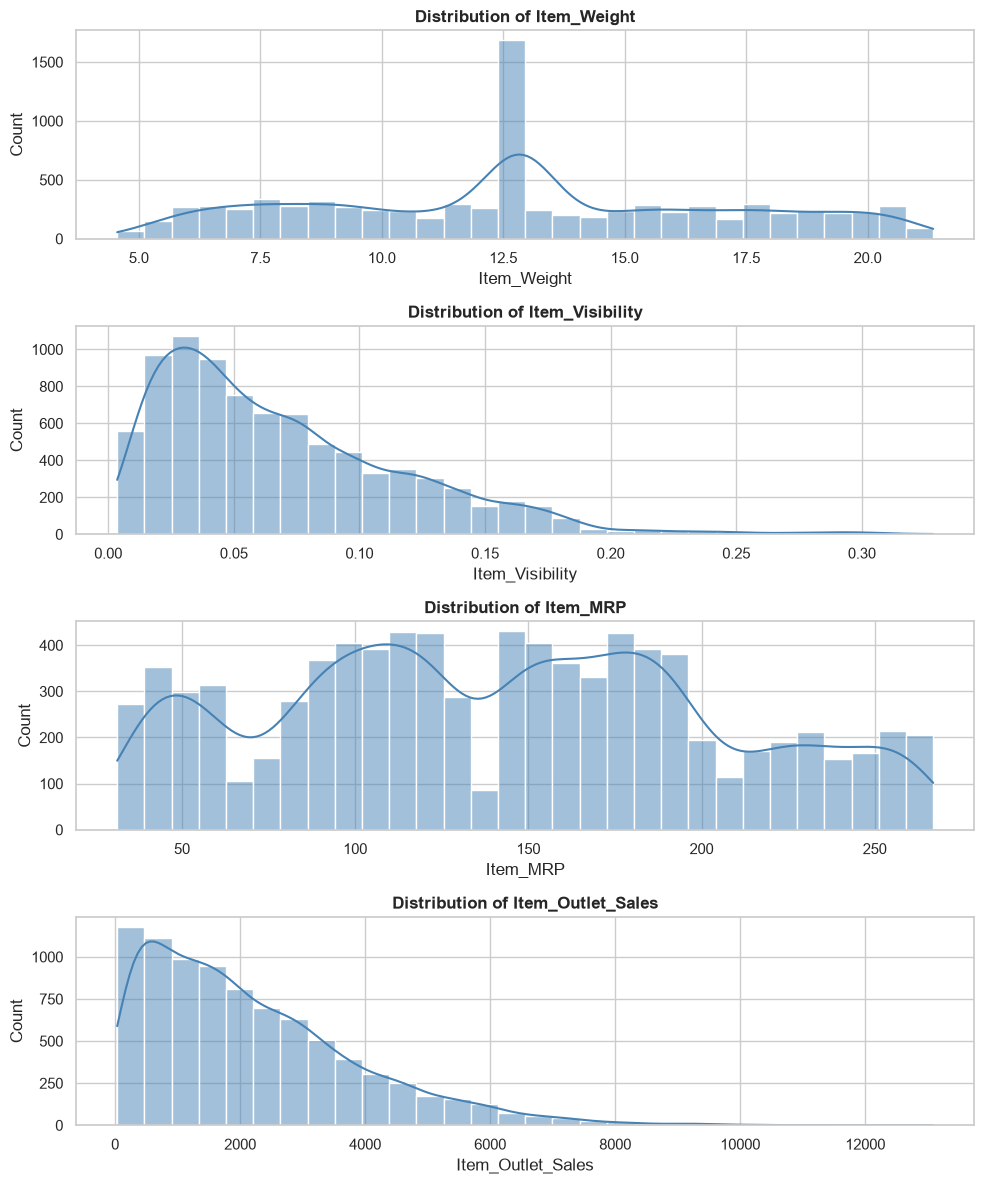

In [26]:
num_to_plot = [col for col in num_cols if col != 'Outlet_Establishment_Year']

fig, axes = plt.subplots(len(num_to_plot), 1, figsize=(10, 12))
for i, col in enumerate(num_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Task 7: Relationship Between Independent Variables and Target Variable

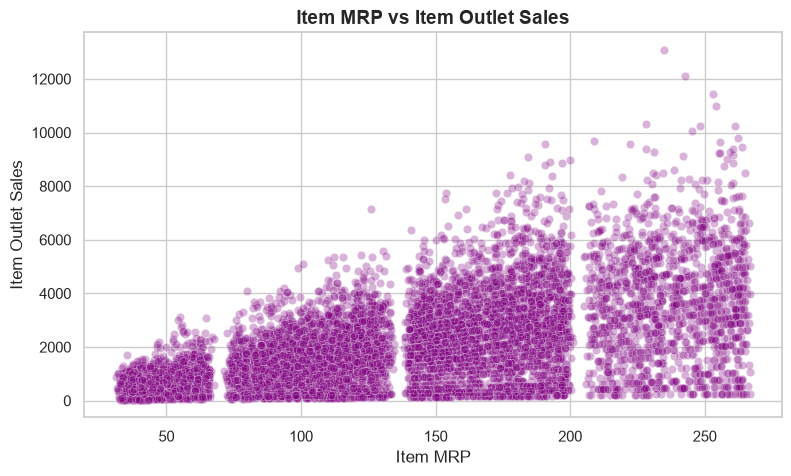

C:\Users\Srajan.Agrawal\AppData\Local\Temp\ipykernel_17096\2606514830.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df, palette='Set2')


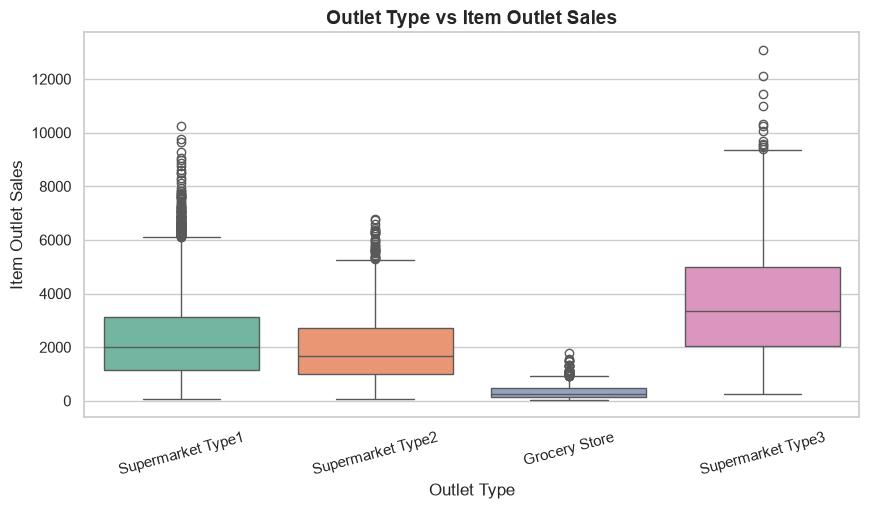

C:\Users\Srajan.Agrawal\AppData\Local\Temp\ipykernel_17096\2606514830.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Item_Fat_Content', y='Item_Outlet_Sales', data=df, palette='Set1')


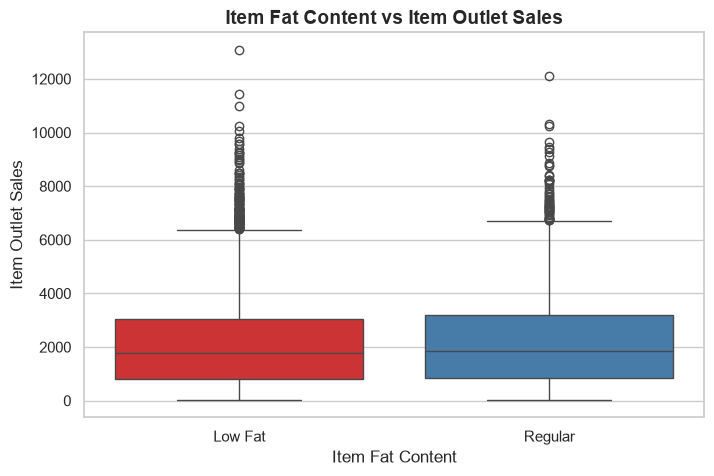

In [27]:
# 1. Item_MRP vs Item_Outlet_Sales
plt.figure(figsize=(9, 5))
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=df, alpha=0.3, color='purple')
plt.title('Item MRP vs Item Outlet Sales', fontsize=14, fontweight='bold')
plt.xlabel('Item MRP')
plt.ylabel('Item Outlet Sales')
plt.show()

# 2. Outlet_Type vs Item_Outlet_Sales
plt.figure(figsize=(10, 5))
sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df, palette='Set2')
plt.xticks(rotation=15)
plt.title('Outlet Type vs Item Outlet Sales', fontsize=14, fontweight='bold')
plt.xlabel('Outlet Type')
plt.ylabel('Item Outlet Sales')
plt.show()

# 3. Item_Fat_Content vs Item_Outlet_Sales
plt.figure(figsize=(8, 5))
sns.boxplot(x='Item_Fat_Content', y='Item_Outlet_Sales', data=df, palette='Set1')
plt.title('Item Fat Content vs Item Outlet Sales', fontsize=14, fontweight='bold')
plt.xlabel('Item Fat Content')
plt.ylabel('Item Outlet Sales')
plt.show()

## Task 8: Visualize Correlations Using Correlation Matrix

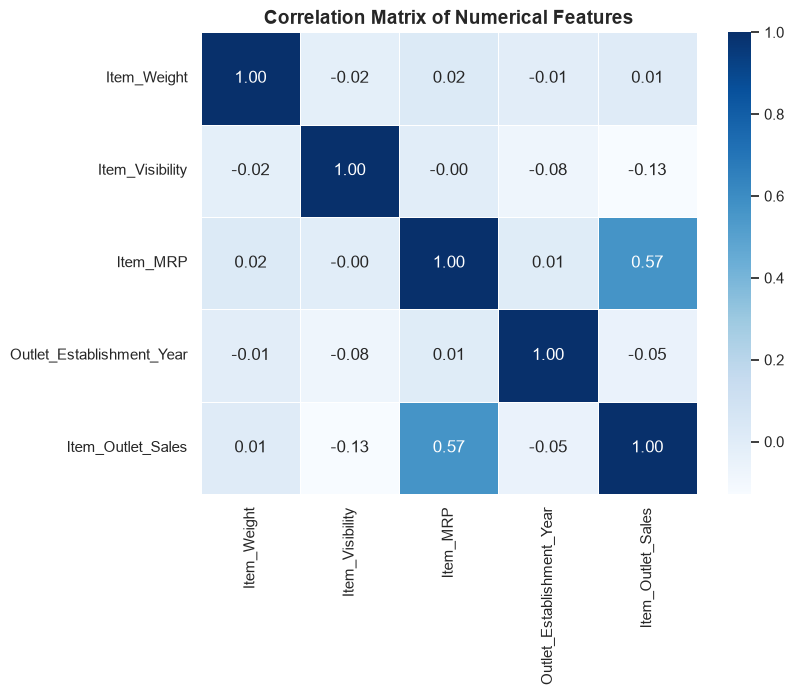

In [28]:
plt.figure(figsize=(8, 6))
correlation_matrix = df[num_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.show()

## Task 9: Encode Categorical Variables & Feature Engineering

In [29]:
# Derive Outlet Age
df['Outlet_Age'] = 2026 - df['Outlet_Establishment_Year']

# Drop raw non-predictive IDs
df_model = df.drop(columns=['Item_Identifier', 'Outlet_Identifier', 'Outlet_Establishment_Year'])

# One-Hot Encoding for remaining categorical variables
df_model = pd.get_dummies(df_model, drop_first=True)

print("Dataset shape after encoding:", df_model.shape)
df_model.head()

Dataset shape after encoding: (8523, 28)


,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales,Outlet_Age,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,...,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,3735.1380,27,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
1,5.92,0.019278,48.2692,443.4228,17,True,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
2,17.50,0.016760,141.6180,2097.2700,27,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
3,19.20,0.015274,182.0950,732.3800,28,True,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
4,8.93,0.008082,53.8614,994.7052,39,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False


## Tasks 10 & 11: Define X, y and Split Training/Testing Sets

In [30]:
# Task 11: Define X and y
X = df_model.drop(columns=['Item_Outlet_Sales'])
y = df_model['Item_Outlet_Sales']

# Task 10: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (6818, 27)
X_test shape:  (1705, 27)
y_train shape: (6818,)
y_test shape:  (1705,)


## Task 12: Build and Train Linear Regression Model

In [31]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression Model successfully trained!")
print(f"Model Intercept: {model.intercept_:.4f}")

Linear Regression Model successfully trained!
Model Intercept: -241.1707


## Task 13: Predict Sales for Test Dataset

In [32]:
y_pred = model.predict(X_test)

# Display first 10 predictions vs actuals
results_df = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred.round(2),
    'Residual/Error': (y_test.values - y_pred).round(2)
})

results_df.head(10)

,Actual Sales,Predicted Sales,Residual/Error
0,1743.0644,1356.05,387.02
1,356.8688,710.82,-353.95
2,377.5086,876.31,-498.80
3,5778.4782,4228.26,1550.22
4,2356.9320,3253.03,-896.10
5,865.5400,635.19,230.35
6,4613.9940,4767.65,-153.66
7,2410.8618,2042.49,368.37
8,1948.1308,1388.10,560.03
9,1937.4780,2780.93,-843.45


## Task 14: Evaluate Model Performance

In [33]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("=== Model Performance Metrics ===")
print(f"R² Score: {r2:.4f}")
print(f"MAE:      {mae:.2f}")
print(f"MSE:      {mse:.2f}")
print(f"RMSE:     {rmse:.2f}")

=== Model Performance Metrics ===
R² Score: 0.5788
MAE:      792.61
MSE:      1144815.00
RMSE:     1069.96


## Task 15: Interpret Coefficients

=== Feature Coefficients ===
                        Feature  Coefficient
  Outlet_Type_Supermarket Type3  3582.938922
  Outlet_Type_Supermarket Type1  1599.258751
  Outlet_Type_Supermarket Type2  1320.945960
              Item_Type_Seafood   228.301771
            Item_Type_Breakfast    66.026530
       Item_Fat_Content_Regular    44.573585
Item_Type_Fruits and Vegetables    44.148013
               Item_Type_Canned    26.735941
        Item_Type_Starchy Foods    22.548265
                       Item_MRP    15.667521
   Item_Type_Health and Hygiene    15.571173
          Item_Type_Hard Drinks     5.247585
                 Item_Type_Meat     2.015109
                    Item_Weight    -1.759016
          Item_Type_Snack Foods    -8.644256
         Item_Type_Frozen Foods   -10.946010
            Item_Type_Household   -13.789277
                     Outlet_Age   -22.461043
               Item_Type_Breads   -25.717017
          Item_Type_Soft Drinks   -28.701003
               Item_Type_O

C:\Users\Srajan.Agrawal\AppData\Local\Temp\ipykernel_17096\2358249334.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coefficients, palette='vlag')


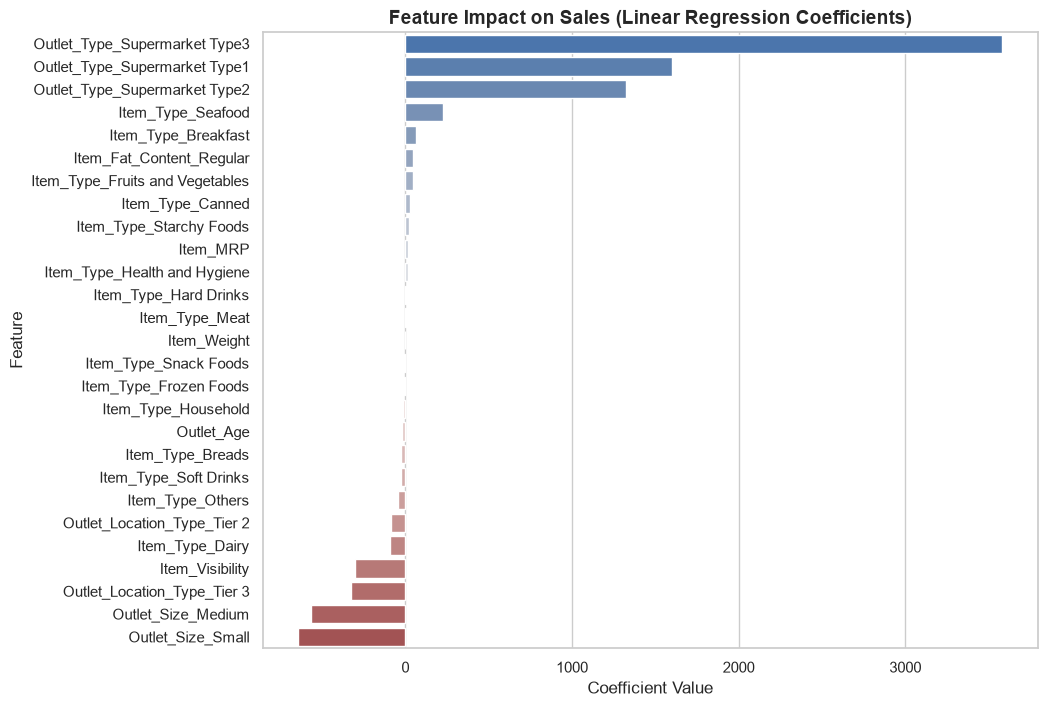

In [34]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("=== Feature Coefficients ===")
print(coefficients.to_string(index=False))

# Plot feature coefficients
plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=coefficients, palette='vlag')
plt.title('Feature Impact on Sales (Linear Regression Coefficients)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

## Task 16: Key Insights and Summary

### Key Findings:
Data Preprocessing Insights

Missing values in Item_Weight and Outlet_Size were handled using appropriate imputation techniques.
Inconsistent values in Item_Fat_Content were standardized to improve data quality.

Feature Impact

Item_MRP was the most influential numerical feature affecting sales.
Outlet_Type_Supermarket Type3 showed the strongest positive impact on sales performance.
Outlet_Type_Grocery Store had a negative influence on sales compared to supermarket outlets.

Model Performance

The Linear Regression model achieved an R² score of approximately 0.58.
The model explained about 58% of the variation in sales data.
